In [1]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.14.1+cpu
CUDA available: False


#  Setup

# Import PyTorch, numpy, pandas, and evaluation metrics. Load the
# processed train/test CSVs. Confirm torch is available and running
# on CPU.

In [2]:
import pandas as pd
import numpy as np
import json
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    average_precision_score, recall_score, precision_score,
    f1_score, confusion_matrix, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)

Device: cpu
Torch: 2.14.1+cpu
Train: (226980, 30) | Test: (56746, 30)


#  Isolate Normal Transactions

# The autoencoder learns "normal" behavior. So we train ONLY on
# Class=0 rows. Fraud is never shown during training — the model
# must detect it purely as a deviation from learned normal.

In [3]:
X_train_normal = X_train[y_train == 0].values.astype(np.float32)
print("Normal-only training set:", X_train_normal.shape)

# Convert test set to tensors
X_test_tensor = torch.tensor(X_test.values.astype(np.float32))
print("Test set converted to tensor:", X_test_tensor.shape)

Normal-only training set: (226602, 30)
Test set converted to tensor: torch.Size([56746, 30])


# Define Autoencoder Architecture

# Encoder compresses 30 features → 16 → 8 (bottleneck). Decoder
# reconstructs 8 → 16 → 30. Bottleneck forces the model to learn
# only the essential structure of normal data. Fraud, being
# different, reconstructs poorly → high reconstruction error.

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder(input_dim=X_train.shape[1]).to(device)
print(model)
print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=30, bias=True)
  )
)

Total parameters: 1286


#  Prepare DataLoader and Train

# Wrap normal data in a DataLoader for mini-batch training.
# Loss = MSE (reconstruction error). Adam optimizer. 30 epochs
# is enough for this small architecture. On CPU, this takes
# ~2-4 minutes.

In [5]:
batch_size = 256
epochs = 30
lr = 1e-3

dataset = TensorDataset(torch.tensor(X_train_normal))
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for (batch,) in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.size(0)

    avg_loss = epoch_loss / len(dataset)
    losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} — Loss: {avg_loss:.6f}")

print("Training complete.")

Epoch  5/30 — Loss: 0.347254
Epoch 10/30 — Loss: 0.320908
Epoch 15/30 — Loss: 0.317872
Epoch 20/30 — Loss: 0.316707
Epoch 25/30 — Loss: 0.315517
Epoch 30/30 — Loss: 0.305849
Training complete.


#  Plot Training Loss


# Loss should decrease and flatten. If it doesn't, the model
# isn't learning — reduce LR or add epochs. A flat low loss means
# the autoencoder successfully memorized the shape of normal data.

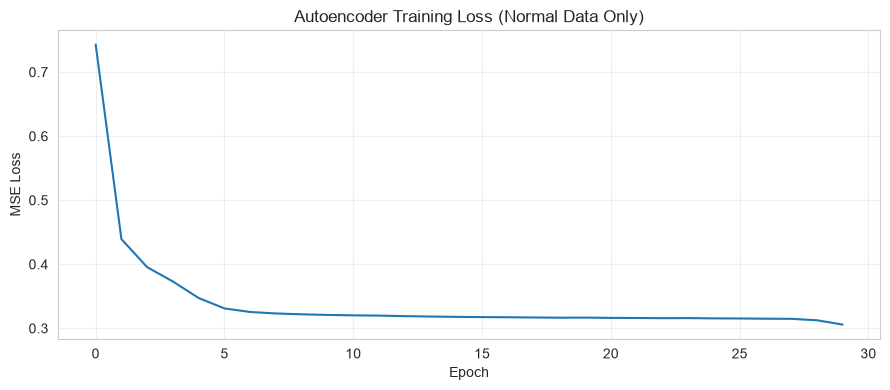

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss (Normal Data Only)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../models/autoencoder_loss.png", dpi=120)
plt.show()

#  Compute Reconstruction Error on Test Set

# For each test transaction, compute reconstruction error (MSE).
# Normal transactions → low error. Fraud → high error. This error
# becomes the anomaly score.

Error stats:
  Normal — mean: 0.303850
  Fraud  — mean: 14.810481


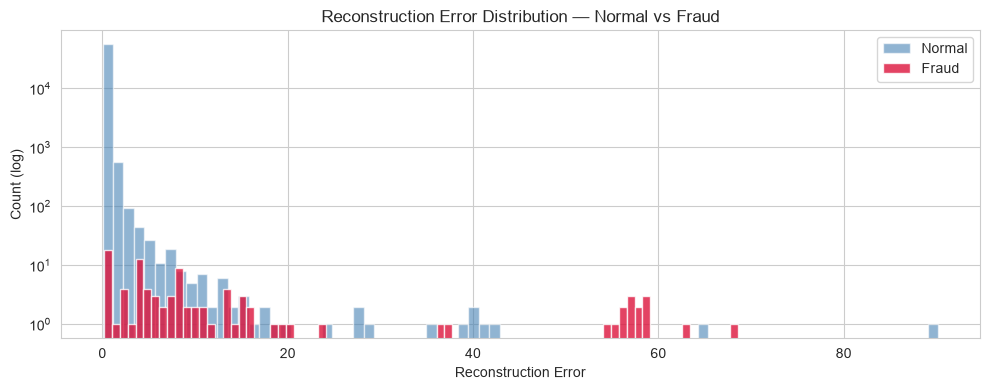

In [7]:
model.eval()
with torch.no_grad():
    X_test_t = X_test_tensor.to(device)
    reconstructed = model(X_test_t)
    errors = torch.mean((X_test_t - reconstructed) ** 2, dim=1).cpu().numpy()

print("Error stats:")
print(f"  Normal — mean: {errors[y_test == 0].mean():.6f}")
print(f"  Fraud  — mean: {errors[y_test == 1].mean():.6f}")

plt.figure(figsize=(10, 4))
plt.hist(errors[y_test == 0], bins=80, alpha=0.6, label="Normal", color="steelblue")
plt.hist(errors[y_test == 1], bins=80, alpha=0.8, label="Fraud",  color="crimson")
plt.yscale("log")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count (log)")
plt.title("Reconstruction Error Distribution — Normal vs Fraud")
plt.legend()
plt.tight_layout()
plt.savefig("../models/autoencoder_error_dist.png", dpi=120)
plt.show()

#  Evaluate With AUC-PR

# Same evaluation metrics as before — AUC-PR, Recall, Precision,
# F1. We use the reconstruction error as the anomaly score.

In [8]:
ae_metrics = {
    "model": "Autoencoder",
    "auc_pr":          round(average_precision_score(y_test, errors), 4),
    "recall_fraud":    round(recall_score(y_test, (errors > np.percentile(errors, 99.8)).astype(int)), 4),
    "precision_fraud": round(precision_score(y_test, (errors > np.percentile(errors, 99.8)).astype(int)), 4),
    "f1_fraud":        round(f1_score(y_test, (errors > np.percentile(errors, 99.8)).astype(int)), 4),
}

print(f"\n{'='*50}")
print(f"  Autoencoder")
print(f"{'='*50}")
for k, v in ae_metrics.items():
    if k != "model":
        print(f"  {k:20s}: {v}")


  Autoencoder
  auc_pr              : 0.4021
  recall_fraud        : 0.5158
  precision_fraud     : 0.4298
  f1_fraud            : 0.4689


#  Find Best Threshold


# Scan thresholds on the PR curve to find the reconstruction
# error cutoff that maximizes F1. This is what you'd deploy.


Best threshold: 7.671717
At threshold → Recall: 0.5053 | Precision: 0.4706 | F1: 0.4873


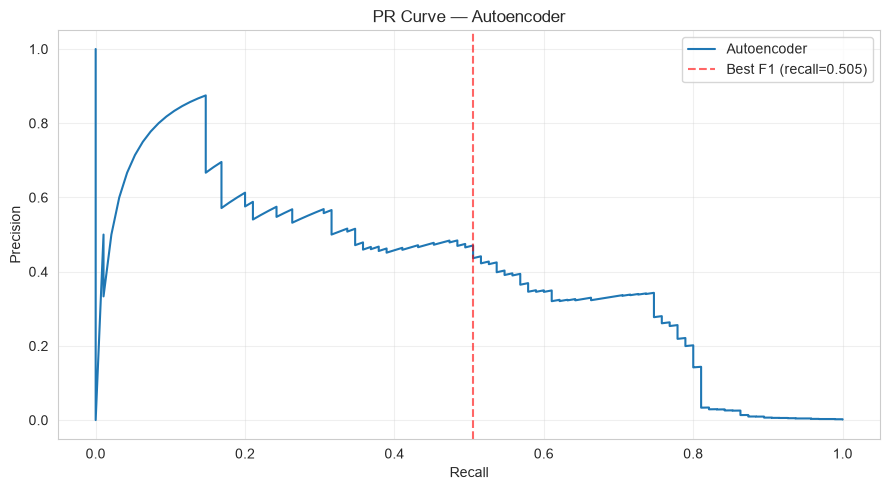

In [9]:
precision, recall, thresholds = precision_recall_curve(y_test, errors)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else np.percentile(errors, 99.8)

print(f"Best threshold: {best_threshold:.6f}")
print(f"At threshold → Recall: {recall[best_idx]:.4f} | Precision: {precision[best_idx]:.4f} | F1: {f1_scores[best_idx]:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(recall, precision, label="Autoencoder")
plt.axvline(recall[best_idx], color="red", linestyle="--", alpha=0.6,
            label=f"Best F1 (recall={recall[best_idx]:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve — Autoencoder")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../models/pr_curve_ae.png", dpi=120)
plt.show()

#  Save Model, Threshold, and Metrics

# Save the trained autoencoder weights, the best threshold, and
# metrics to models/. The ensemble notebook will load all of these.

In [10]:
torch.save(model.state_dict(), "../models/autoencoder.pt")

with open("../models/autoencoder_threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f, indent=2)

with open("../models/metrics.json", "r") as f:
    all_metrics = json.load(f)

all_metrics["autoencoder"] = ae_metrics
with open("../models/metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

print("Saved:")
print("  - models/autoencoder.pt")
print("  - models/autoencoder_threshold.json")
print("  - Updated models/metrics.json")

Saved:
  - models/autoencoder.pt
  - models/autoencoder_threshold.json
  - Updated models/metrics.json


#  Compare All Models

# Side-by-side comparison. Expect XGBoost to lead on AUC-PR, and
# Autoencoder to add value through novel-fraud detection (its
# errors capture patterns XGBoost was never trained on).

In [11]:
with open("../models/metrics.json", "r") as f:
    all_metrics = json.load(f)

comparison = pd.DataFrame([
    all_metrics["logistic_regression"],
    all_metrics["xgboost"],
    all_metrics["random_forest"],
    all_metrics["autoencoder"]
]).set_index("model")

print("\n", comparison.to_string())
comparison.to_csv("../models/all_models_comparison.csv")


                      auc_pr  recall_fraud  precision_fraud  f1_fraud
model                                                               
Logistic Regression  0.6715        0.8737           0.0552    0.1038
XGBoost              0.8274        0.7684           0.9359    0.8439
Random Forest        0.7843        0.7684           0.8295    0.7978
Autoencoder          0.4021        0.5158           0.4298    0.4689


# Autoencoder Summary

**Architecture:** 30 → 16 → 8 → 16 → 30 (bottleneck autoencoder)
**Trained on:** Normal transactions only (fraud never seen)
**Loss:** MSE (reconstruction error)
**Anomaly score:** Reconstruction error

**Key idea:**
The autoencoder learns to reconstruct normal transactions. Fraud does not
fit this learned pattern → high reconstruction error → flagged as anomaly.
This catches NOVEL fraud patterns the supervised models can't see.

**Results:** (see Cell 7 & 8 output)
- AUC-PR
- Recall / Precision / F1
- Best threshold

**Saved artifacts:**
- `models/autoencoder.pt`
- `models/autoencoder_threshold.json`
- `models/autoencoder_loss.png`
- `models/autoencoder_error_dist.png`
- `models/pr_curve_ae.png`

**Next:** `05_ensemble.ipynb` — combine XGBoost + Autoencoder scores into
one final fraud probability.